In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits import mplot3d

In [3]:
cancer = pd.read_csv('/Users/madeleineyu/DSI_assignments/LCR/01_materials/notebooks/dataset/wdbc.csv')
cancer

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [4]:
cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
cancer['diagnosis'].unique()

array(['M', 'B'], dtype=object)

In [6]:
cancer['diagnosis'] = cancer['diagnosis'].replace({
    "M": "Malignant",
    "B": "Benign"
})

In [7]:
cancer['diagnosis'].unique()

array(['Malignant', 'Benign'], dtype=object)

In [8]:
cancer['diagnosis'].value_counts(normalize = True)

diagnosis
Benign       0.627417
Malignant    0.372583
Name: proportion, dtype: float64

In [9]:
cancer.groupby('diagnosis').size()

diagnosis
Benign       357
Malignant    212
dtype: int64

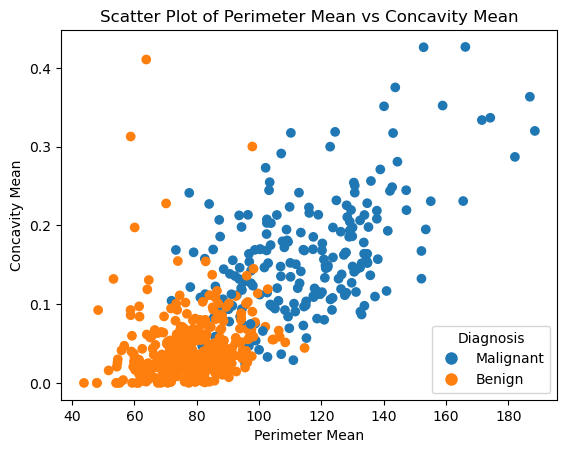

In [10]:
# Create mapping between values and colors
labels = cancer["diagnosis"].unique().tolist()
colors = list(mcolors.TABLEAU_COLORS.keys())
color_map = {l: colors[i % len(colors)] for i, l in enumerate(labels)}

# Plot
plt.scatter(cancer['perimeter_mean'], cancer['concavity_mean'],
            color=cancer["diagnosis"].map(color_map))

# Create custom legend handles
handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                      markersize=10, markerfacecolor=color_map[label])
                      for label in labels]

# Add labels and legend
plt.xlabel('Perimeter Mean')
plt.ylabel('Concavity Mean')
plt.title('Scatter Plot of Perimeter Mean vs Concavity Mean')
plt.legend(handles=handles, title='Diagnosis')
plt.show()

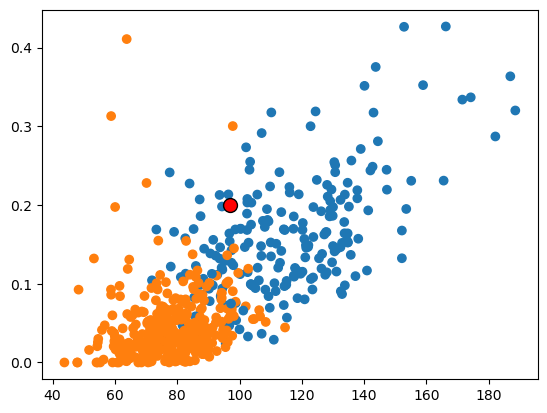

In [11]:
# Plot existing data
plt.scatter(cancer['perimeter_mean'], cancer['concavity_mean'],
            color=cancer["diagnosis"].map(color_map))

# Create custom legend handles
handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                      markersize=10, markerfacecolor=color_map[label])
                      for label in labels]

# Add new observation
new_observation = {'perimeter_mean': 97, 'concavity_mean': 0.20}
plt.scatter(new_observation['perimeter_mean'], new_observation['concavity_mean'],
            color='red', edgecolor='black', s=100, label='New Observation')

In [12]:
new_obs_Perimeter = 97
new_obs_Concavity = 0.20

In [13]:
cancer['dist_from_new'] = (
    (cancer["perimeter_mean"] - new_obs_Perimeter)**2 +
    (cancer["concavity_mean"] - new_obs_Concavity)**2) **(1/2)


In [14]:
cancer['dist_from_new']

0      25.800194
1      35.900178
2      33.000000
3      19.420044
4      38.100000
         ...    
564    45.000021
565    34.200046
566    11.300511
567    43.100266
568    49.080407
Name: dist_from_new, Length: 569, dtype: float64

In [15]:
# K = 5

nearest_5 = cancer.nsmallest(5, "dist_from_new")[[
    "perimeter_mean",
    "concavity_mean",
    "diagnosis",
    "dist_from_new"
]]

In [16]:
nearest_5

,perimeter_mean,concavity_mean,diagnosis,dist_from_new
291,97.03,0.05940,Benign,0.143765
138,96.85,0.15390,Malignant,0.156924
15,96.73,0.16390,Malignant,0.272403
514,97.26,0.07486,Malignant,0.288548
54,97.26,0.05253,Malignant,0.298910


<module 'matplotlib.pyplot' from '/opt/miniconda3/envs/dsi_participant/lib/python3.9/site-packages/matplotlib/pyplot.py'>

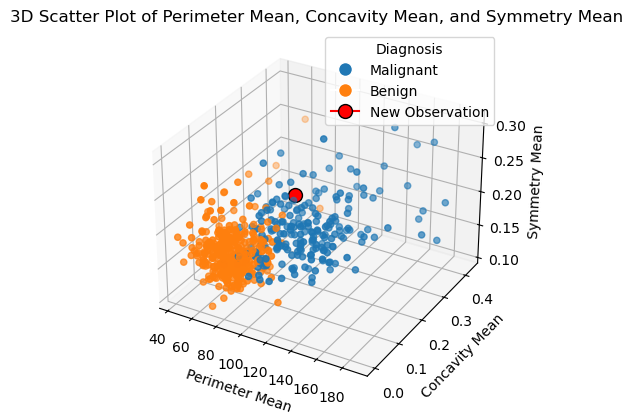

In [17]:
# Create mapping between values and colors
labels = cancer["diagnosis"].unique().tolist()
colors = list(mcolors.TABLEAU_COLORS.keys())
color_map = {l: colors[i % len(colors)] for i, l in enumerate(labels)}

# Create a 3D plot
ax = plt.axes(projection="3d")

# Plot data points with color corresponding to diagnosis
sc = ax.scatter3D(cancer['perimeter_mean'], cancer['concavity_mean'], cancer['symmetry_mean'],
                  c=cancer['diagnosis'].map(color_map), marker='o')

# Define the new observation
new_observation = {'perimeter_mean': 97, 'concavity_mean': 0.20, 'symmetry_mean': 0.22}

# Plot the new observation
ax.scatter3D(new_observation['perimeter_mean'], new_observation['concavity_mean'],
             new_observation['symmetry_mean'], color='red', edgecolor='black',
             s=100, marker='o', label='New Observation')

# Add axis labels
ax.set_xlabel('Perimeter Mean')
ax.set_ylabel('Concavity Mean')
ax.set_zlabel('Symmetry Mean')
ax.set_title('3D Scatter Plot of Perimeter Mean, Concavity Mean, and Symmetry Mean')

# Create custom legend handles
handles = [plt.Line2D([0], [0], marker='o', color='w', label=label,
                      markersize=10, markerfacecolor=color_map[label])
                      for label in labels]

# Add custom legend for new observation
handles.append(plt.Line2D([0], [0], marker='o', color='red', label='New Observation',
                          markersize=10, markeredgecolor='black'))

# Add legend
plt.legend(handles=handles, title='Diagnosis')

# Show plot
plt


In [18]:
# perimeter mean of 97, concavity mean of 0.2, symmetry mean 0.22

new_obs_Perimeter = 97
new_obs_Concavity = 0.20
new_obs_Symmetry = 0.22

In [19]:
cancer['dist_from_new'] = (
    (cancer['perimeter_mean'] - new_obs_Perimeter) **2 +
    (cancer['concavity_mean'] - new_obs_Concavity) **2 +
    (cancer['symmetry_mean'] - new_obs_Symmetry) **2) **(1/2) 



In [20]:
cancer['dist_from_new']

0      25.800203
1      35.900199
2      33.000003
3      19.420085
4      38.100020
         ...    
564    45.000046
565    34.200075
566    11.300676
567    43.100270
568    49.080446
Name: dist_from_new, Length: 569, dtype: float64

In [21]:
nearest_5 = cancer.nsmallest(5, 'dist_from_new')[[
    "perimeter_mean",
    "concavity_mean",
    "symmetry_mean",
    "diagnosis",
    "dist_from_new"
]]

In [22]:
nearest_5

,perimeter_mean,concavity_mean,symmetry_mean,diagnosis,dist_from_new
291,97.03,0.05940,0.1879,Benign,0.147305
138,96.85,0.15390,0.1957,Malignant,0.158795
15,96.73,0.16390,0.2303,Malignant,0.272597
514,97.26,0.07486,0.1561,Malignant,0.295539
54,97.26,0.05253,0.1616,Malignant,0.304562


In [23]:
from sklearn import set_config

In [24]:
# outputs dataframes instead of arrays
set_config(transform_output = "pandas")

In [25]:
from sklearn.neighbors import KNeighborsClassifier

In [26]:
cancer_train = cancer[['diagnosis', 'perimeter_mean', 'concavity_mean']]
cancer_train

,diagnosis,perimeter_mean,concavity_mean
0,Malignant,122.80,0.30010
1,Malignant,132.90,0.08690
2,Malignant,130.00,0.19740
3,Malignant,77.58,0.24140
4,Malignant,135.10,0.19800
...,...,...,...
564,Malignant,142.00,0.24390
565,Malignant,131.20,0.14400
566,Malignant,108.30,0.09251
567,Malignant,140.10,0.35140


In [27]:
knn = KNeighborsClassifier(n_neighbors= 5)
knn

KNeighborsClassifier()

In [28]:
#define predictors and response variables
x = cancer_train[['perimeter_mean', 'concavity_mean']]
y = cancer_train['diagnosis']

In [29]:
knn.fit(x,y)

KNeighborsClassifier()

In [30]:
new_obs = pd.DataFrame({'perimeter_mean' : [97],
                        'concavity_mean': [0.20]})
new_obs

,perimeter_mean,concavity_mean
0,97,0.2


In [31]:
knn.predict(new_obs)

array(['Malignant'], dtype=object)

In [32]:
# Classification II - Mar 4

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score, precision_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import GridSearchCV

In [34]:
cancer['diagnosis']

0      Malignant
1      Malignant
2      Malignant
3      Malignant
4      Malignant
         ...    
564    Malignant
565    Malignant
566    Malignant
567    Malignant
568       Benign
Name: diagnosis, Length: 569, dtype: object

In [35]:
standardized_cancer = cancer.copy()

In [36]:
columns_to_exclude = ['id', 'diagnosis']
columns_to_scale = standardized_cancer.columns.difference(columns_to_exclude)

In [38]:
scaler = StandardScaler()
standardized_cancer[columns_to_scale] = scaler.fit_transform(standardized_cancer[columns_to_scale])
standardized_cancer

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,dist_from_new
0,842302,Malignant,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,...,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015,0.382425
1,842517,Malignant,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,...,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190,1.101023
2,84300903,Malignant,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,...,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391,0.894679
3,84348301,Malignant,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,...,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010,-0.071510
4,84358402,Malignant,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,...,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100,1.257537
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,Malignant,2.110995,0.721473,2.060786,2.343856,1.041842,0.219060,1.947285,2.320965,...,0.117700,1.752563,2.015301,0.378365,-0.273318,0.664512,1.629151,-1.360158,-0.709091,1.748463
565,926682,Malignant,1.704854,2.085134,1.615931,1.723842,0.102458,-0.017833,0.693043,1.263669,...,2.047399,1.421940,1.494959,-0.691230,-0.394820,0.236573,0.733827,-0.531855,-0.973978,0.980062
566,926954,Malignant,0.702284,2.045574,0.672676,0.577953,-0.840484,-0.038680,0.046588,0.105777,...,1.374854,0.579001,0.427906,-0.809587,0.350735,0.326767,0.414069,-1.104549,-0.318409,-0.649193
567,927241,Malignant,1.838341,2.336457,1.982524,1.735218,1.525767,3.272144,3.296944,2.658866,...,2.237926,2.303601,1.653171,1.430427,3.904848,3.197605,2.289985,1.919083,2.219635,1.613297


In [ ]:
# set the seed

np.random.seed(1)

#split the data
cancer_train, cancer_test = train_test_split(
    standardized_cancer, train_size = 0.75, shuffle = True, stratify = standardized_cancer['diagnosis']
)

cancer_train

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,dist_from_new
164,8712289,Malignant,2.596659,0.640025,2.476807,2.932585,-0.851870,0.192528,0.547405,1.240713,...,0.414075,2.291686,2.676276,-0.419448,0.661808,0.588232,1.827097,1.113428,0.439125,2.467062
28,852973,Malignant,0.333066,1.391668,0.429654,0.220449,0.842579,1.238650,0.998129,0.995412,...,1.796619,1.252161,0.682803,1.390974,2.269333,1.733401,1.336800,1.822016,0.820940,-1.069005
378,9013594,Benign,-0.132717,-0.963324,-0.152364,-0.211286,-0.973563,-0.546958,-0.581412,-0.624450,...,-0.983124,-0.277044,-0.393040,-0.213419,0.357097,-0.073347,-0.140179,0.786637,0.689050,-0.831985
131,8670,Malignant,0.378508,0.044296,0.400820,0.267377,0.913744,0.340350,0.725686,0.824140,...,0.052562,0.525386,0.484159,0.974533,-0.094562,0.512911,0.560244,-0.103143,-0.208132,-1.118793
233,88206102,Malignant,1.812780,1.982743,1.747740,1.888800,-0.339479,0.057973,0.836170,0.889399,...,1.905725,1.651291,1.742824,-0.441366,0.138901,0.683223,0.634854,-0.750255,-0.036897,1.207739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,901034302,Benign,-0.450813,-0.283820,-0.516897,-0.463558,-1.565660,-1.475202,-1.099882,-1.121268,...,-0.764914,-0.608859,-0.518379,-1.728826,-1.342223,-1.288651,-1.496108,-1.080282,-1.592419,-0.202340
301,892604,Benign,-0.473535,0.139706,-0.475295,-0.522146,-0.843330,-0.055736,-0.257368,-0.462464,...,-0.424570,-0.569839,-0.578851,-1.199727,-0.244691,-0.392382,-0.584035,-0.349045,-0.349442,-0.274248
406,905189,Benign,0.571638,-1.030809,0.507915,0.412710,-0.100363,-0.366351,-0.424349,-0.093868,...,-0.992895,0.257314,0.118337,-0.515887,-0.522048,-0.197603,-0.025980,-0.198592,-0.766169,-0.933722
27,852781,Malignant,1.273153,0.223480,1.241101,1.248876,-0.139504,0.042812,0.755818,0.732313,...,0.257745,0.972174,0.918363,0.062747,-0.270773,0.347396,0.523700,-0.905562,-0.539518,0.332614


In [41]:
# fit model with k = 5
knn = KNeighborsClassifier(n_neighbors=5)
knn

KNeighborsClassifier()

In [42]:
# define predictor variable (x) and response variable (y)

x = cancer_train[["perimeter_mean","concavity_mean"]]
y = cancer_train["diagnosis"]

In [43]:
knn.fit(x,y)

KNeighborsClassifier()

In [45]:
cancer_test['predicted'] = knn.predict(cancer_test[["perimeter_mean", "concavity_mean"]])

In [46]:
cancer_test[['id','diagnosis','predicted']]

,id,diagnosis,predicted
357,901028,Benign,Benign
361,901041,Benign,Benign
212,8810703,Malignant,Malignant
527,91813702,Benign,Benign
21,8510824,Benign,Benign
...,...,...,...
364,9010877,Benign,Benign
434,908469,Benign,Benign
299,892399,Benign,Benign
488,913512,Benign,Benign


In [47]:
knn.score(
    cancer_test[['perimeter_mean','concavity_mean']], cancer_test['diagnosis']
)

0.9230769230769231

In [48]:
pd.crosstab(
    cancer_test['diagnosis'],
    cancer_test['predicted'],
    rownames = ['Actual'],
    colnames = ['Predicted']
    )

Predicted,Benign,Malignant
Actual,,
Benign,88,2
Malignant,9,44


In [50]:
precision_score(
    y_true = cancer_test['diagnosis'],
    y_pred = cancer_test['predicted'],
    pos_label = "Malignant"
)

0.9565217391304348

In [51]:
recall_score(
    y_true = cancer_test['diagnosis'],
    y_pred = cancer_test['predicted'],
    pos_label = "Malignant"
)

0.8301886792452831

In [61]:
# now we are splitting our training data into train and validation splits

cancer_subtrain, cancer_validation = train_test_split(
    cancer_train, train_size= 0.75, stratify = cancer_train['diagnosis']
)

In [62]:
#fit the model on the sub training data

knn = KNeighborsClassifier(n_neighbors= 3)
x = cancer_subtrain[["perimeter_mean", "concavity_mean"]]
y = cancer_subtrain["diagnosis"]
knn.fit(x,y)

KNeighborsClassifier(n_neighbors=3)

In [63]:
#compute the score on validation data

acc = knn.score(
    cancer_validation[["perimeter_mean", "concavity_mean"]],
    cancer_validation["diagnosis"]
)
acc

0.8785046728971962

In [68]:
# 5 fold cross validation

knn = KNeighborsClassifier(n_neighbors=3)
x = cancer_train[["perimeter_mean", "concavity_mean"]]
y = cancer_train["diagnosis"]

returned_dictionary = cross_validate(
    estimator = knn,
    cv = 5,
    X = x,
    y = y
)

cv_5_df = pd.DataFrame(returned_dictionary)
cv_5_df

,fit_time,score_time,test_score
0,0.013297,0.007958,0.930233
1,0.001821,0.003271,0.894118
2,0.001216,0.002825,0.870588
3,0.001092,0.002695,0.952941
4,0.000993,0.002569,0.917647


In [69]:
cv_5_metrics = cv_5_df.agg(["mean","sem"])
cv_5_metrics

,fit_time,score_time,test_score
mean,0.003684,0.003864,0.913105
sem,0.002408,0.001030,0.014264


In [83]:
parameter_grid = {
    "n_neighbors": range(1,100,5)
}

In [85]:
cancer_tune_grid = GridSearchCV(
    estimator = knn,
    param_grid = parameter_grid,
    cv = 10
)

In [86]:
cancer_tune_grid.fit(
    cancer_train[["perimeter_mean","concavity_mean"]],
    cancer_train["diagnosis"]
)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(n_neighbors=3),
             param_grid={'n_neighbors': range(1, 100, 5)})

In [87]:
accuracy_grid = pd.DataFrame(cancer_tune_grid.cv_results_)
accuracy_grid

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.001749,0.002360,0.002214,0.001402,1,{'n_neighbors': 1},0.953488,0.837209,0.906977,0.860465,0.813953,0.837209,0.880952,0.904762,0.880952,0.880952,0.875692,0.038684,20
1,0.000843,0.000038,0.001566,0.000097,6,{'n_neighbors': 6},0.930233,0.953488,0.906977,0.837209,0.837209,0.906977,0.928571,0.928571,0.880952,0.976190,0.908638,0.043373,18
2,0.000849,0.000048,0.001732,0.000342,11,{'n_neighbors': 11},0.906977,0.930233,0.906977,0.837209,0.837209,0.883721,0.952381,0.904762,0.928571,0.952381,0.904042,0.039147,19
3,0.000864,0.000080,0.001662,0.000224,16,{'n_neighbors': 16},0.906977,0.953488,0.930233,0.837209,0.837209,0.930233,0.952381,0.952381,0.928571,0.976190,0.920487,0.045315,1
4,0.001106,0.000165,0.002398,0.001058,21,{'n_neighbors': 21},0.906977,0.953488,0.930233,0.837209,0.837209,0.906977,0.952381,0.952381,0.880952,0.976190,0.913400,0.046495,11
5,0.001031,0.000153,0.002033,0.000452,26,{'n_neighbors': 26},0.906977,0.953488,0.930233,0.837209,0.837209,0.906977,0.952381,0.928571,0.904762,0.976190,0.913400,0.043989,11
6,0.000903,0.000182,0.001652,0.000082,31,{'n_neighbors': 31},0.906977,0.953488,0.930233,0.837209,0.837209,0.906977,0.952381,0.928571,0.904762,0.976190,0.913400,0.043989,11
7,0.000943,0.000221,0.001752,0.000113,36,{'n_neighbors': 36},0.906977,0.953488,0.930233,0.837209,0.837209,0.883721,0.928571,0.952381,0.904762,0.976190,0.911074,0.044873,16
8,0.000854,0.000042,0.001782,0.000219,41,{'n_neighbors': 41},0.906977,0.953488,0.930233,0.837209,0.837209,0.883721,0.952381,0.928571,0.904762,0.976190,0.911074,0.044873,16
9,0.000806,0.000022,0.001643,0.000038,46,{'n_neighbors': 46},0.906977,0.953488,0.930233,0.837209,0.837209,0.906977,0.952381,0.952381,0.904762,0.976190,0.915781,0.045368,8


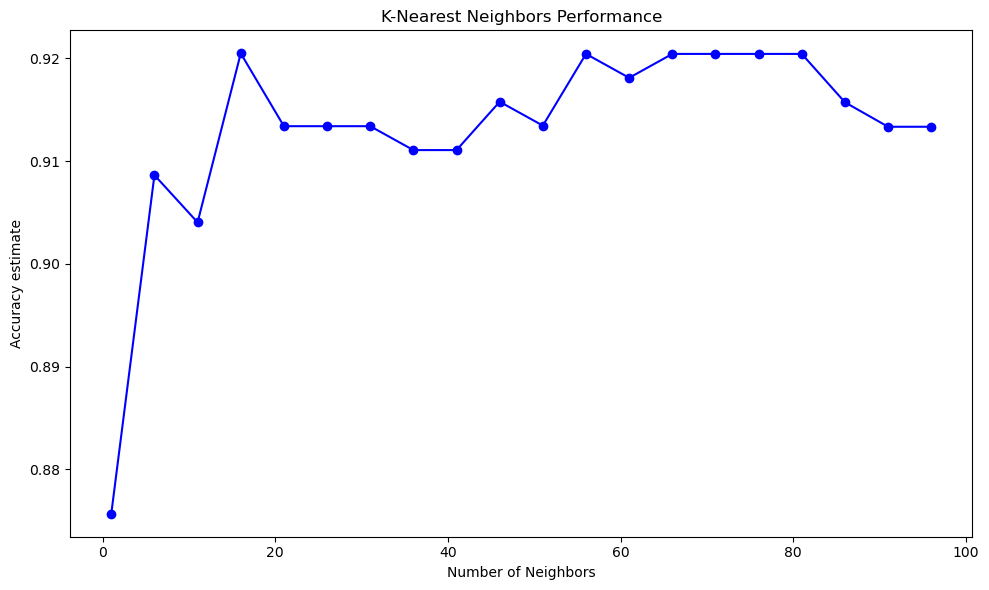

In [88]:
# Create the plot
plt.figure(figsize=(10, 6))

# Plot mean test scores with error bars
plt.plot(accuracy_grid['param_n_neighbors'], accuracy_grid['mean_test_score'], '-o', color='blue')

# Add labels and legend
plt.xlabel('Number of Neighbors')
plt.ylabel('Accuracy estimate')
plt.title('K-Nearest Neighbors Performance')
plt.tight_layout()
plt.show()